# Project Overview

This project simulates a digital plant phenotyping pipeline to investigate how multi-modal sensor data can be used to predict final crop yield at early growth stages.

The goal is to replicate a simplified version of real-world agricultural phenotyping systems used in controlled environment agriculture and breeding programs.

#### Objectives
- Simulate realistic plant phenotyping data (morphological, physiological, environmental)
- Engineer biologically meaningful features from raw sensor signals
- Model plant growth dynamics over time
- Predict final yield using early-stage data
- Identify key drivers of plant performance

### **1. Create a Synthetic Dataset**

The dataset includes time-series measurements per plant:
#### Imaging-derived features
- **Normalized Difference Vegetation Index (NDVI)** → plant health / greenness  
  - NDVI is calculated as $NDVI = \frac{NIR - Red}{NIR + Red}$.
  - **NIR**: Near-infrared light reflected by plants  
  - **Red**: Red light absorbed by chlorophyll  

- **Greenness index** → proxy for chlorophyll content  
- **Canopy volume** → 3D plant structure (LiDAR-like)

#### Environmental sensors (time-varying)
- **Temperature**
- **Humidity**
- **CO₂**
- **Light intensity**

#### Stress indicators
- **Water stress index**

#### Growth traits
- **Plant height**
- **Leaf area**

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [16]:
np.random.seed(42)

n_plants = 50
n_days = 30

plant_ids = [f"P{i}" for i in range(1, n_plants + 1)]
days = np.arange(1, n_days + 1)

data = []

for plant in plant_ids:
    temperature = np.random.choice([18, 22, 26])
    light_cat = np.random.choice(["low", "medium", "high"])
    treatment = np.random.choice(["control", "fertilizer"])

    # map light to numeric intensity
    light_map = {"low": 200, "medium": 400, "high": 700}
    light_intensity_base = light_map[light_cat]

    base_growth_rate = 0.3 + (temperature - 18) * 0.02

    if light_cat == "medium":
        base_growth_rate += 0.1
    elif light_cat == "high":
        base_growth_rate += 0.2

    if treatment == "fertilizer":
        base_growth_rate += 0.15

    height = 5

    for day in days:
        noise = np.random.normal(0, 0.2)

        # growth
        growth = base_growth_rate * np.exp(-day / 40)
        height += growth + noise

        leaf_area = height * np.random.uniform(1.8, 2.5)

        # Environmental variation over time
        humidity = np.random.normal(60, 5)
        co2 = np.random.normal(400, 20)
        light_intensity = light_intensity_base + np.random.normal(0, 30)

        # Sensor-like features (correlated with plant state)
        ndvi = 0.3 + 0.02 * height + np.random.normal(0, 0.02)
        greenness = 0.5 + 0.03 * height + np.random.normal(0, 0.03)

        canopy_volume = height * leaf_area * np.random.uniform(0.8, 1.2)

        # Water stress (inverse of good conditions)
        water_stress = (
            1 / (light_intensity / 500 + humidity / 100 + 0.1)
            + np.random.normal(0, 0.02)
        )

        data.append([
            plant, day, height, leaf_area,
            temperature, light_cat, light_intensity,
            humidity, co2,
            ndvi, greenness, canopy_volume,
            water_stress,
            treatment
        ])

df = pd.DataFrame(data, columns=[
    "plant_id", "day", "height", "leaf_area",
    "temperature", "light", "light_intensity",
    "humidity", "co2",
    "ndvi", "greenness_index", "canopy_volume",
    "water_stress_index",
    "treatment"
])

df.to_csv("plant_growth_sensor_data.csv", index=False)

df.head()

,plant_id,day,height,leaf_area,temperature,light,light_intensity,humidity,co2,ndvi,greenness_index,canopy_volume,water_stress_index,treatment
0,P1,1,5.578180,10.649935,26,low,230.315459,67.615149,405.580826,0.399946,0.651590,51.884027,0.813389,control
1,P1,2,5.633090,11.842791,26,low,187.158618,64.082225,369.522480,0.397814,0.647892,74.321312,0.853956,control
2,P1,3,6.073357,13.450605,26,low,184.536930,52.876259,402.444383,0.409462,0.710624,68.543813,0.990134,control
3,P1,4,6.860038,12.934100,26,low,193.116486,57.331756,399.889443,0.444988,0.667848,89.440660,0.965636,control
4,P1,5,7.000350,17.351831,26,low,226.452831,60.984306,404.372766,0.419825,0.662512,110.359294,0.850818,control


2. Growth curves

<Axes: xlabel='ndvi', ylabel='height'>

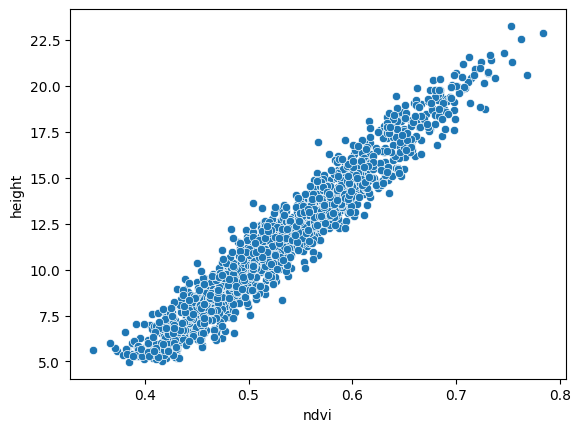

In [14]:
sns.scatterplot(data=df, x="ndvi", y="height")

--> NDVI increases with plant height → proxy for plant health.

3. modeling

In [15]:
model = smf.ols(
    "height ~ day + temperature + light_intensity + ndvi + water_stress_index + treatment",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     6768.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:22:58   Log-Likelihood:                -1629.4
No. Observations:                1500   AIC:                             3273.
Df Residuals:                    1493   BIC:                             3310.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

4. Regression model

In [9]:
# Convert categorical variables
df["light"] = df["light"].astype("category")
df["treatment"] = df["treatment"].astype("category")

model = smf.ols(
    "height ~ day + temperature + light + treatment",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     3210.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:14:37   Log-Likelihood:                -2185.9
No. Observations:                1500   AIC:                             4384.
Df Residuals:                    1494   BIC:                             4416.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [10]:
model2 = smf.ols(
    "height ~ day * temperature + light + treatment",
    data=df
).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     2735.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:15:04   Log-Likelihood:                -2170.2
No. Observations:                1500   AIC:                             4354.
Df Residuals:                    1493   BIC:                             4392.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [11]:
print(model2.params)

Intercept                  4.057700
light[T.low]              -2.495428
light[T.medium]           -1.584676
treatment[T.fertilizer]    1.527256
day                        0.254598
temperature                0.118979
day:temperature            0.005018
dtype: float64


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# pivot to wide format
pivot = df.pivot(index="plant_id", columns="day", values="height")

# normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pivot)

# cluster
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pivot["cluster"] = clusters

print(pivot["cluster"].value_counts())

cluster
0    23
2    18
1     9
Name: count, dtype: int64
